# FastF1 2025 — Local Preprocessing & EDA v2
## XYZ Position Merge Fix for Tableau Circuit Telemetry

Notebook ini menggantikan notebook FastF1 sebelumnya.

### Masalah yang diperbaiki

Pada output sebelumnya, `x`, `y`, dan `z` kosong karena `car_data` dan `pos_data`
digabung menggunakan exact timestamp:

```python
car.merge(pos, on="Time", how="left")
```

Sampling timestamp kedua sumber telemetry tidak selalu identik.

### Solusi v2

Notebook ini menggunakan **nearest-time merge** dengan `pandas.merge_asof`.
Notebook mencoba tolerance kecil terlebih dahulu dan hanya memperlebarnya jika
coverage posisi belum mencukupi.

Selain itu notebook:
- memproses musim **2025**,
- menggunakan 5 circuit yang sama dengan scope project,
- memilih podium P1–P3,
- mengambil fastest valid lap,
- mempertahankan 27 kolom output agar kompatibel dengan workbook Tableau,
- membuat audit kualitas merge posisi,
- memvalidasi bahwa `x/y/z` benar-benar terisi sebelum export.

### Struktur project

```text
F1_Tableau_Project/
├── data/
│   └── fastf1_cache/
├── notebook/
│   └── 02_fastf1_preprocessing_eda_local_v2_xyz_fix.ipynb
└── outputs/
    ├── fastf1_telemetry_2025_selected_circuits.csv
    ├── fastf1_fastest_lap_summary_2025.csv
    └── fastf1_position_merge_audit_2025.csv
```

## 1. Install Dependencies

In [1]:
%pip install -q "fastf1==3.8.3" pandas numpy matplotlib pyarrow


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Imports & Project Paths

In [2]:
from pathlib import Path
import re
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import fastf1

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

cwd = Path.cwd().resolve()

if cwd.name.lower() == "notebook":
    PROJECT_DIR = cwd.parent
else:
    PROJECT_DIR = cwd

DATA_DIR = PROJECT_DIR / "data"
CACHE_DIR = DATA_DIR / "fastf1_cache"
OUTPUT_DIR = PROJECT_DIR / "outputs"

for folder in [DATA_DIR, CACHE_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

SEASON = 2025
SESSION_CODE = "R"

fastf1.Cache.enable_cache(str(CACHE_DIR))

print("FastF1 version :", fastf1.__version__)
print("Project dir    :", PROJECT_DIR)
print("Cache dir      :", CACHE_DIR)
print("Output dir     :", OUTPUT_DIR)

FastF1 version : 3.8.3
Project dir    : /home/user/projects/avd-uts
Cache dir      : /home/user/projects/avd-uts/data/fastf1_cache
Output dir     : /home/user/projects/avd-uts/outputs


## 3. Target Circuits

Scope project:
- Monaco
- Great Britain
- Italy
- Belgium
- Austria

In [3]:
TARGET_EVENTS = {
    "Monaco": ["Monaco"],
    "Great Britain": ["British", "Great Britain"],
    "Italy": ["Italian", "Italy"],
    "Belgium": ["Belgian", "Belgium"],
    "Austria": ["Austrian", "Austria"],
}

## 4. Load 2025 Event Schedule

In [4]:
schedule = fastf1.get_event_schedule(
    SEASON,
    include_testing=False
)

show_cols = [
    c for c in [
        "RoundNumber",
        "Country",
        "Location",
        "EventName",
        "EventDate"
    ]
    if c in schedule.columns
]

display(schedule[show_cols])

,RoundNumber,Country,Location,EventName,EventDate
1,1,Australia,Melbourne,Australian Grand Prix,2025-03-16
2,2,China,Shanghai,Chinese Grand Prix,2025-03-23
3,3,Japan,Suzuka,Japanese Grand Prix,2025-04-06
4,4,Bahrain,Sakhir,Bahrain Grand Prix,2025-04-13
5,5,Saudi Arabia,Jeddah,Saudi Arabian Grand Prix,2025-04-20
6,6,United States,Miami Gardens,Miami Grand Prix,2025-05-04
7,7,Italy,Imola,Emilia Romagna Grand Prix,2025-05-18
8,8,Monaco,Monaco,Monaco Grand Prix,2025-05-25
9,9,Spain,Barcelona,Spanish Grand Prix,2025-06-01
10,10,Canada,Montréal,Canadian Grand Prix,2025-06-15


## 5. Resolve Event Names

In [5]:
def normalize_text(value):
    return re.sub(
        r"[^a-z0-9]+",
        " ",
        str(value).lower()
    ).strip()

def resolve_event_name(schedule_df, aliases):
    for alias in aliases:
        alias_norm = normalize_text(alias)

        for _, row in schedule_df.iterrows():
            combined = " ".join([
                str(row.get("EventName", "")),
                str(row.get("Country", "")),
                str(row.get("Location", ""))
            ])

            if alias_norm in normalize_text(combined):
                return str(row["EventName"])

    return None

resolved_events = {
    label: resolve_event_name(schedule, aliases)
    for label, aliases in TARGET_EVENTS.items()
}

print(resolved_events)

missing = [
    label
    for label, event_name in resolved_events.items()
    if event_name is None
]

if missing:
    raise ValueError(
        f"Event gagal di-resolve: {missing}"
    )

{'Monaco': 'Monaco Grand Prix', 'Great Britain': 'British Grand Prix', 'Italy': 'Italian Grand Prix', 'Belgium': 'Belgian Grand Prix', 'Austria': 'Austrian Grand Prix'}


## 6. Core Helper Functions

In [6]:
def timedelta_to_seconds(value):
    if pd.isna(value):
        return np.nan

    try:
        return value.total_seconds()
    except Exception:
        return np.nan


def load_race_session(year, event_name):
    session = fastf1.get_session(
        year,
        event_name,
        SESSION_CODE
    )

    session.load(
        laps=True,
        telemetry=True,
        weather=False,
        messages=False
    )

    if session.laps is None or session.laps.empty:
        raise RuntimeError(
            f"No lap data for {year} {event_name}"
        )

    return session


def get_podium(session):
    results = session.results.copy()

    results["Position"] = pd.to_numeric(
        results["Position"],
        errors="coerce"
    )

    podium = (
        results
        .dropna(subset=["Position"])
        .sort_values("Position")
        .head(3)
        .copy()
    )

    return podium


def get_fastest_valid_lap(session, driver_abbr):
    driver_laps = session.laps.pick_drivers(
        driver_abbr
    )

    if driver_laps.empty:
        return None

    accurate = driver_laps.pick_accurate()

    if not accurate.empty:
        fastest = accurate.pick_fastest()
    else:
        fastest = driver_laps.pick_fastest()

    if fastest is None:
        return None

    if getattr(fastest, "empty", False):
        return None

    return fastest

## 7. Position Merge Fix

Kunci perbaikan ada di fungsi berikut.

Daripada exact join berdasarkan timestamp, fungsi:
1. mengambil `car_data`,
2. mengambil `pos_data`,
3. mengurutkan keduanya berdasarkan waktu,
4. melakukan nearest-time merge,
5. mencoba tolerance 50 → 100 → 200 → 500 → 1000 ms,
6. jika masih rendah, menggunakan nearest match tanpa tolerance,
7. menghitung selisih timestamp sebagai audit.

Tidak ada interpolasi manual pada `x/y/z`; nilai posisi diambil dari sample posisi terdekat.

In [7]:
POSITION_TOLERANCES_MS = [
    50,
    100,
    200,
    500,
    1000,
    None
]

TARGET_POSITION_COVERAGE = 0.98


def xyz_coverage(df):
    needed = ["X", "Y", "Z"]

    if not set(needed).issubset(df.columns):
        return 0.0

    if len(df) == 0:
        return 0.0

    return (
        df[needed]
        .notna()
        .all(axis=1)
        .mean()
    )


def merge_car_and_position(
    fastest_lap,
    target_coverage=TARGET_POSITION_COVERAGE
):
    car = (
        fastest_lap
        .get_car_data()
        .add_distance()
        .copy()
    )

    pos = (
        fastest_lap
        .get_pos_data()
        .copy()
    )

    if car.empty:
        raise ValueError(
            "Car telemetry is empty."
        )

    if pos.empty:
        raise ValueError(
            "Position telemetry is empty."
        )

    if "Time" not in car.columns:
        raise KeyError(
            "Car telemetry has no Time column."
        )

    if "Time" not in pos.columns:
        raise KeyError(
            "Position telemetry has no Time column."
        )

    car = (
        car
        .sort_values("Time")
        .drop_duplicates(
            subset=["Time"],
            keep="first"
        )
        .reset_index(drop=True)
    )

    pos = (
        pos
        .sort_values("Time")
        .drop_duplicates(
            subset=["Time"],
            keep="first"
        )
        .reset_index(drop=True)
    )

    pos_keep = [
        c for c in [
            "Time",
            "Date",
            "Status",
            "X",
            "Y",
            "Z",
            "Source",
            "SessionTime"
        ]
        if c in pos.columns
    ]

    pos_work = pos[pos_keep].copy()

    rename_pos = {
        "Time": "pos_time",
        "Date": "Date_pos",
        "Source": "Source_pos",
        "SessionTime": "SessionTime_pos"
    }

    pos_work.rename(
        columns=rename_pos,
        inplace=True
    )

    best = None
    best_coverage = -1.0
    best_tolerance = None

    for tolerance_ms in POSITION_TOLERANCES_MS:
        tolerance = (
            None
            if tolerance_ms is None
            else pd.Timedelta(
                milliseconds=tolerance_ms
            )
        )

        merged = pd.merge_asof(
            car,
            pos_work,
            left_on="Time",
            right_on="pos_time",
            direction="nearest",
            tolerance=tolerance
        )

        coverage = xyz_coverage(merged)

        if coverage > best_coverage:
            best = merged.copy()
            best_coverage = coverage
            best_tolerance = tolerance_ms

        if coverage >= target_coverage:
            break

    if best is None:
        raise RuntimeError(
            "Position merge produced no result."
        )

    best["position_time_delta_ms"] = (
        (
            best["Time"]
            - best["pos_time"]
        )
        .abs()
        .dt.total_seconds()
        * 1000
    )

    return (
        best,
        best_tolerance,
        best_coverage
    )

## 8. Build Clean 27-Column Output

Output mempertahankan schema yang sama seperti CSV sebelumnya supaya Tableau tidak perlu dirombak.

In [8]:
OUTPUT_COLUMNS = [
    "rpm",
    "speed_kmh",
    "gear",
    "throttle_pct",
    "brake",
    "drs",
    "Source",
    "distance_m",
    "Date_pos",
    "Status",
    "x",
    "y",
    "z",
    "Source_pos",
    "SessionTime_pos",
    "season",
    "circuit",
    "event_name",
    "driver",
    "driver_number",
    "team",
    "finish_position",
    "lap_number",
    "lap_time_seconds",
    "compound",
    "time_seconds",
    "session_time_seconds",
]

assert len(OUTPUT_COLUMNS) == 27


def series_or_nan(df, column):
    if column in df.columns:
        return df[column]

    return pd.Series(
        np.nan,
        index=df.index
    )


def build_output_frame(
    merged,
    circuit_label,
    event_name,
    result_row,
    fastest_lap
):
    out = pd.DataFrame(
        index=merged.index
    )

    out["rpm"] = pd.to_numeric(
        series_or_nan(merged, "RPM"),
        errors="coerce"
    )

    out["speed_kmh"] = pd.to_numeric(
        series_or_nan(merged, "Speed"),
        errors="coerce"
    )

    out["gear"] = pd.to_numeric(
        series_or_nan(merged, "nGear"),
        errors="coerce"
    )

    out["throttle_pct"] = pd.to_numeric(
        series_or_nan(merged, "Throttle"),
        errors="coerce"
    )

    out["brake"] = series_or_nan(
        merged,
        "Brake"
    )

    out["drs"] = pd.to_numeric(
        series_or_nan(merged, "DRS"),
        errors="coerce"
    )

    out["Source"] = series_or_nan(
        merged,
        "Source"
    )

    out["distance_m"] = pd.to_numeric(
        series_or_nan(merged, "Distance"),
        errors="coerce"
    )

    out["Date_pos"] = series_or_nan(
        merged,
        "Date_pos"
    )

    out["Status"] = series_or_nan(
        merged,
        "Status"
    )

    out["x"] = pd.to_numeric(
        series_or_nan(merged, "X"),
        errors="coerce"
    )

    out["y"] = pd.to_numeric(
        series_or_nan(merged, "Y"),
        errors="coerce"
    )

    out["z"] = pd.to_numeric(
        series_or_nan(merged, "Z"),
        errors="coerce"
    )

    out["Source_pos"] = series_or_nan(
        merged,
        "Source_pos"
    )

    out["SessionTime_pos"] = series_or_nan(
        merged,
        "SessionTime_pos"
    )

    out["season"] = SEASON
    out["circuit"] = circuit_label
    out["event_name"] = event_name

    out["driver"] = result_row.get(
        "Abbreviation"
    )

    out["driver_number"] = result_row.get(
        "DriverNumber"
    )

    out["team"] = result_row.get(
        "TeamName"
    )

    out["finish_position"] = pd.to_numeric(
        result_row.get("Position"),
        errors="coerce"
    )

    out["lap_number"] = pd.to_numeric(
        fastest_lap.get(
            "LapNumber",
            np.nan
        ),
        errors="coerce"
    )

    out["lap_time_seconds"] = (
        timedelta_to_seconds(
            fastest_lap.get(
                "LapTime",
                pd.NaT
            )
        )
    )

    out["compound"] = fastest_lap.get(
        "Compound",
        None
    )

    if "Time" in merged.columns:
        out["time_seconds"] = (
            merged["Time"]
            .dt.total_seconds()
        )
    else:
        out["time_seconds"] = np.nan

    if "SessionTime" in merged.columns:
        out["session_time_seconds"] = (
            merged["SessionTime"]
            .dt.total_seconds()
        )
    else:
        out["session_time_seconds"] = np.nan

    return out[OUTPUT_COLUMNS]

## 9. Extract All Five Circuits × Podium Drivers

In [9]:
telemetry_frames = []
summary_rows = []
merge_audit_rows = []
error_rows = []

for circuit_label, event_name in resolved_events.items():
    print("=" * 90)
    print(
        f"Processing {SEASON} "
        f"{circuit_label} | {event_name}"
    )

    try:
        session = load_race_session(
            SEASON,
            event_name
        )

        podium = get_podium(session)

        print(
            "Podium:",
            podium["Abbreviation"].tolist()
        )

        for _, result_row in podium.iterrows():
            driver = result_row.get(
                "Abbreviation"
            )

            try:
                fastest_lap = (
                    get_fastest_valid_lap(
                        session,
                        driver
                    )
                )

                if fastest_lap is None:
                    raise ValueError(
                        "No valid fastest lap found."
                    )

                merged, tolerance_ms, coverage = (
                    merge_car_and_position(
                        fastest_lap
                    )
                )

                clean = build_output_frame(
                    merged,
                    circuit_label,
                    event_name,
                    result_row,
                    fastest_lap
                )

                telemetry_frames.append(
                    clean
                )

                delta = pd.to_numeric(
                    merged[
                        "position_time_delta_ms"
                    ],
                    errors="coerce"
                )

                merge_audit_rows.append({
                    "season": SEASON,
                    "circuit": circuit_label,
                    "event_name": event_name,
                    "driver": driver,
                    "merge_tolerance_ms": (
                        "nearest_no_limit"
                        if tolerance_ms is None
                        else tolerance_ms
                    ),
                    "xyz_coverage": coverage,
                    "telemetry_samples": len(clean),
                    "position_delta_ms_median": (
                        delta.median()
                    ),
                    "position_delta_ms_p95": (
                        delta.quantile(0.95)
                    ),
                    "position_delta_ms_max": (
                        delta.max()
                    ),
                })

                speed = pd.to_numeric(
                    clean["speed_kmh"],
                    errors="coerce"
                )

                throttle = pd.to_numeric(
                    clean["throttle_pct"],
                    errors="coerce"
                )

                rpm = pd.to_numeric(
                    clean["rpm"],
                    errors="coerce"
                )

                summary_rows.append({
                    "season": SEASON,
                    "circuit": circuit_label,
                    "event_name": event_name,
                    "driver": driver,
                    "driver_number": result_row.get(
                        "DriverNumber"
                    ),
                    "team": result_row.get(
                        "TeamName"
                    ),
                    "finish_position": pd.to_numeric(
                        result_row.get(
                            "Position"
                        ),
                        errors="coerce"
                    ),
                    "lap_number": pd.to_numeric(
                        fastest_lap.get(
                            "LapNumber",
                            np.nan
                        ),
                        errors="coerce"
                    ),
                    "lap_time_seconds": (
                        timedelta_to_seconds(
                            fastest_lap.get(
                                "LapTime",
                                pd.NaT
                            )
                        )
                    ),
                    "max_speed_kmh": speed.max(),
                    "avg_speed_kmh": speed.mean(),
                    "max_rpm": rpm.max(),
                    "avg_rpm": rpm.mean(),
                    "avg_throttle_pct": (
                        throttle.mean()
                    ),
                    "max_distance_m": (
                        pd.to_numeric(
                            clean["distance_m"],
                            errors="coerce"
                        ).max()
                    ),
                    "telemetry_samples": len(clean),
                    "xyz_coverage": coverage,
                })

                print(
                    f"  ✅ {driver}: "
                    f"{len(clean):,} samples | "
                    f"XYZ coverage={coverage:.1%} | "
                    f"tolerance={tolerance_ms}"
                )

            except Exception as exc:
                error_rows.append({
                    "circuit": circuit_label,
                    "event_name": event_name,
                    "driver": driver,
                    "stage": "driver_extraction",
                    "error": (
                        f"{type(exc).__name__}: "
                        f"{exc}"
                    )
                })

                print(
                    f"  ❌ {driver}: "
                    f"{type(exc).__name__}: "
                    f"{exc}"
                )

        del session
        gc.collect()

    except Exception as exc:
        error_rows.append({
            "circuit": circuit_label,
            "event_name": event_name,
            "driver": None,
            "stage": "session_load",
            "error": (
                f"{type(exc).__name__}: "
                f"{exc}"
            )
        })

        print(
            f"❌ SESSION FAILED: "
            f"{type(exc).__name__}: "
            f"{exc}"
        )

print()
print(
    "Successful telemetry frames:",
    len(telemetry_frames)
)
print(
    "Errors:",
    len(error_rows)
)

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Processing 2025 Monaco | Monaco Grand Prix


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['4', '16', '81', '1', '44', '6', '31', '30', '23', '55', '63', '87', '43', '5', '18', '27', '22', '12', '14', '10']


Podium: ['NOR', 'LEC', 'PIA']
  ✅ NOR: 262 samples | XYZ coverage=98.5% | tolerance=200
  ✅ LEC: 274 samples | XYZ coverage=98.5% | tolerance=200
  ✅ PIA: 271 samples | XYZ coverage=98.9% | tolerance=200


core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


...

Podium: ['PIA', 'NOR', 'LEC']
  ✅ PIA: 386 samples | XYZ coverage=100.0% | tolerance=500
  ✅ NOR: 390 samples | XYZ coverage=99.7% | tolerance=500
  ✅ LEC: 384 samples | XYZ coverage=100.0% | tolerance=500


core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Processing 2025 Austria | Austrian Grand Prix


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '16', '44', '63', '30', '14', '5', '27', '31', '87', '6', '10', '18', '43', '22', '23', '1', '12', '55']


Podium: ['NOR', 'PIA', 'LEC']
  ✅ NOR: 248 samples | XYZ coverage=98.4% | tolerance=200
  ✅ PIA: 243 samples | XYZ coverage=99.2% | tolerance=200
  ✅ LEC: 260 samples | XYZ coverage=98.5% | tolerance=200

Successful telemetry frames: 15
Errors: 0


## 10. Build Master Datasets

In [10]:
if not telemetry_frames:
    error_df = pd.DataFrame(
        error_rows
    )

    if not error_df.empty:
        display(error_df)

    raise RuntimeError(
        "Tidak ada telemetry yang berhasil "
        "diekstrak."
    )

telemetry_master = pd.concat(
    telemetry_frames,
    ignore_index=True
)

telemetry_master = (
    telemetry_master
    .sort_values(
        [
            "circuit",
            "finish_position",
            "driver",
            "distance_m"
        ]
    )
    .reset_index(drop=True)
)

fastest_lap_summary = pd.DataFrame(
    summary_rows
)

position_merge_audit = pd.DataFrame(
    merge_audit_rows
)

extraction_errors = pd.DataFrame(
    error_rows
)

print(
    "Telemetry master:",
    telemetry_master.shape
)

print(
    "Fastest-lap summary:",
    fastest_lap_summary.shape
)

print(
    "Merge audit:",
    position_merge_audit.shape
)

Telemetry master: (4630, 27)
Fastest-lap summary: (15, 17)
Merge audit: (15, 10)


## 11. Critical XYZ Validation

Cell ini **sengaja menghentikan notebook** jika position data masih gagal.

Target:
- overall XYZ coverage ≥ 95%
- setiap circuit-driver ≥ 90%

In [11]:
xyz_valid = (
    telemetry_master[
        ["x", "y", "z"]
    ]
    .notna()
    .all(axis=1)
)

overall_xyz_coverage = (
    xyz_valid.mean()
)

print(
    f"Overall XYZ coverage: "
    f"{overall_xyz_coverage:.2%}"
)

per_driver_xyz = (
    telemetry_master
    .assign(
        xyz_valid=xyz_valid.astype(int)
    )
    .groupby(
        ["circuit", "driver"],
        as_index=False
    )
    .agg(
        rows=("xyz_valid", "size"),
        xyz_coverage=(
            "xyz_valid",
            "mean"
        ),
        x_min=("x", "min"),
        x_max=("x", "max"),
        y_min=("y", "min"),
        y_max=("y", "max"),
    )
)

display(per_driver_xyz)

if overall_xyz_coverage < 0.95:
    raise RuntimeError(
        "XYZ coverage masih di bawah 95%. "
        "Periksa position_merge_audit."
    )

bad_groups = per_driver_xyz.loc[
    per_driver_xyz[
        "xyz_coverage"
    ] < 0.90
]

if not bad_groups.empty:
    display(bad_groups)

    raise RuntimeError(
        "Ada circuit-driver dengan XYZ "
        "coverage di bawah 90%."
    )

print(
    "✅ XYZ validation passed."
)

Overall XYZ coverage: 99.35%


,circuit,driver,rows,xyz_coverage,x_min,x_max,y_min,y_max
0,Austria,LEC,260,0.984615,-8232.0,4244.0,-2243.0,5679.0
1,Austria,NOR,248,0.983871,-8232.0,4245.0,-2242.0,5679.0
2,Austria,PIA,243,0.991770,-8233.0,4242.0,-2243.0,5679.0
3,Belgium,LEC,384,1.000000,-4336.0,8311.0,-15770.0,4548.0
4,Belgium,NOR,390,0.997436,-4337.0,8312.0,-15770.0,4549.0
5,Belgium,PIA,386,1.000000,-4335.0,8313.0,-15769.0,4545.0
6,Great Britain,HUL,335,1.000000,-2313.0,7787.0,-4115.0,13114.0
7,Great Britain,NOR,336,0.997024,-2315.0,7790.0,-4112.0,13115.0
8,Great Britain,PIA,330,1.000000,-2314.0,7789.0,-4117.0,13114.0
9,Italy,NOR,295,0.993220,-1499.0,11067.0,-5802.0,15882.0


✅ XYZ validation passed.


## 12. Merge Quality Audit

In [12]:
display(
    position_merge_audit
    .sort_values(
        ["circuit", "finish_position"]
        if "finish_position"
        in position_merge_audit.columns
        else ["circuit", "driver"]
    )
)

print(
    "Median XYZ coverage:",
    position_merge_audit[
        "xyz_coverage"
    ].median()
)

print(
    "Worst XYZ coverage:",
    position_merge_audit[
        "xyz_coverage"
    ].min()
)

,season,circuit,event_name,driver,merge_tolerance_ms,xyz_coverage,telemetry_samples,position_delta_ms_median,position_delta_ms_p95,position_delta_ms_max
14,2025,Austria,Austrian Grand Prix,LEC,200,0.984615,260,54.0,153.25,188.0
12,2025,Austria,Austrian Grand Prix,NOR,200,0.983871,248,55.0,153.85,194.0
13,2025,Austria,Austrian Grand Prix,PIA,200,0.991770,243,67.0,152.00,187.0
11,2025,Belgium,Belgian Grand Prix,LEC,500,1.000000,384,63.0,174.20,363.0
10,2025,Belgium,Belgian Grand Prix,NOR,500,0.997436,390,63.0,183.00,457.0
9,2025,Belgium,Belgian Grand Prix,PIA,500,1.000000,386,62.5,163.00,422.0
5,2025,Great Britain,British Grand Prix,HUL,500,1.000000,335,67.0,186.30,453.0
3,2025,Great Britain,British Grand Prix,NOR,500,0.997024,336,65.0,166.00,466.0
4,2025,Great Britain,British Grand Prix,PIA,500,1.000000,330,66.0,165.00,453.0
7,2025,Italy,Italian Grand Prix,NOR,200,0.993220,295,66.0,166.00,194.0


Median XYZ coverage: 0.9932203389830508
Worst XYZ coverage: 0.9838709677419355


## 13. EDA — Verify Track Geometry

Plot sederhana untuk memastikan `x/y` benar-benar membentuk lintasan.
Tidak digunakan sebagai dashboard final; hanya quality check.

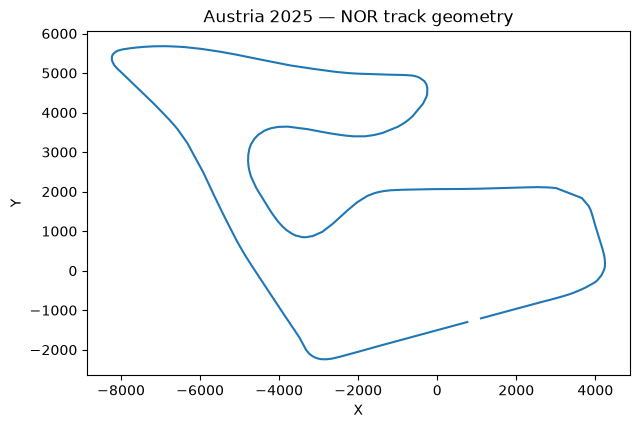

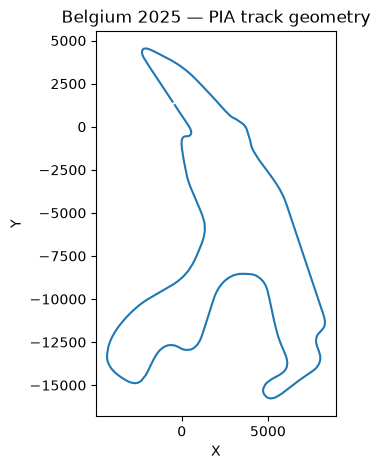

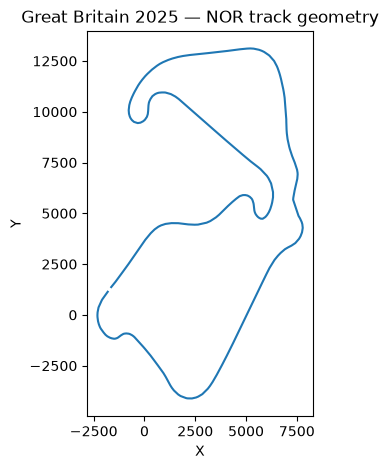

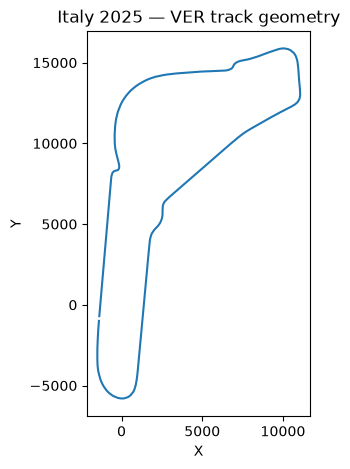

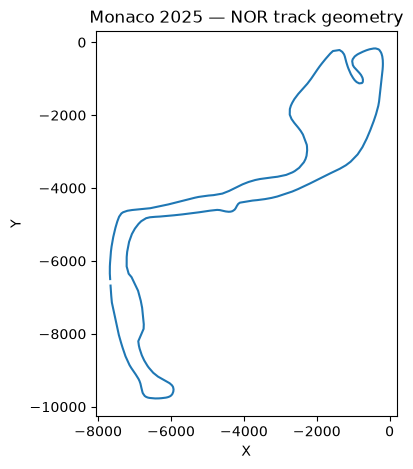

In [13]:
circuits = (
    telemetry_master[
        "circuit"
    ]
    .dropna()
    .unique()
)

for circuit in circuits:
    circuit_df = (
        telemetry_master.loc[
            telemetry_master[
                "circuit"
            ].eq(circuit)
        ]
    )

    first_driver = (
        circuit_df[
            "driver"
        ]
        .dropna()
        .iloc[0]
    )

    check = (
        circuit_df.loc[
            circuit_df[
                "driver"
            ].eq(first_driver)
        ]
        .dropna(
            subset=["x", "y"]
        )
        .sort_values(
            "distance_m"
        )
    )

    fig, ax = plt.subplots(
        figsize=(7, 5)
    )

    ax.plot(
        check["x"],
        check["y"]
    )

    ax.set_title(
        f"{circuit} 2025 — "
        f"{first_driver} track geometry"
    )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    plt.show()

## 14. EDA — Speed vs Distance

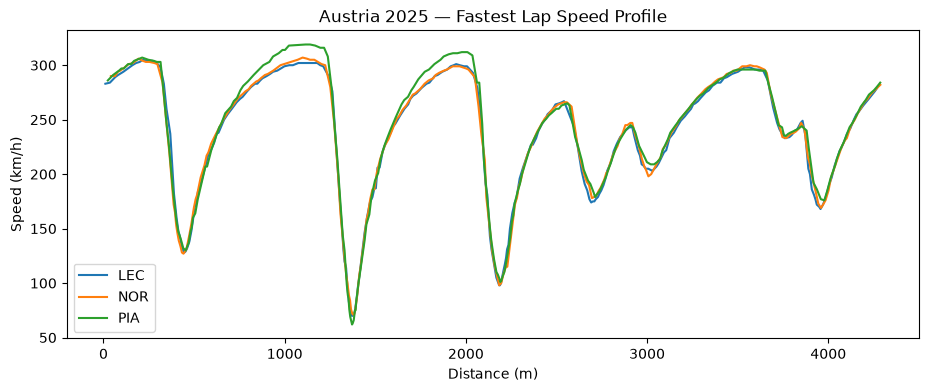

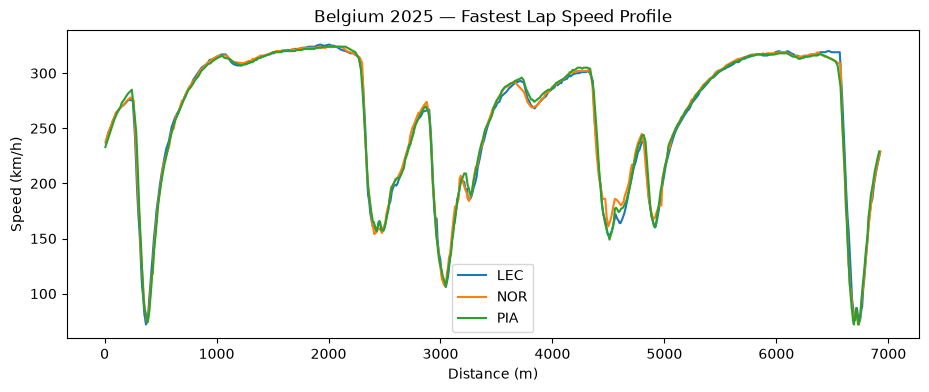

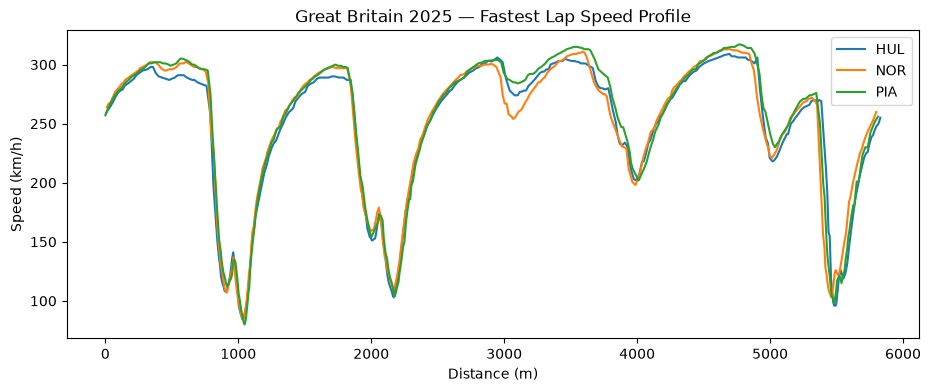

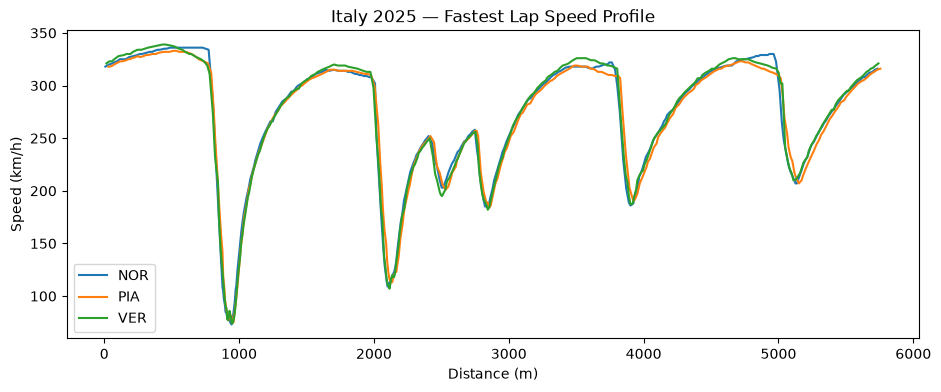

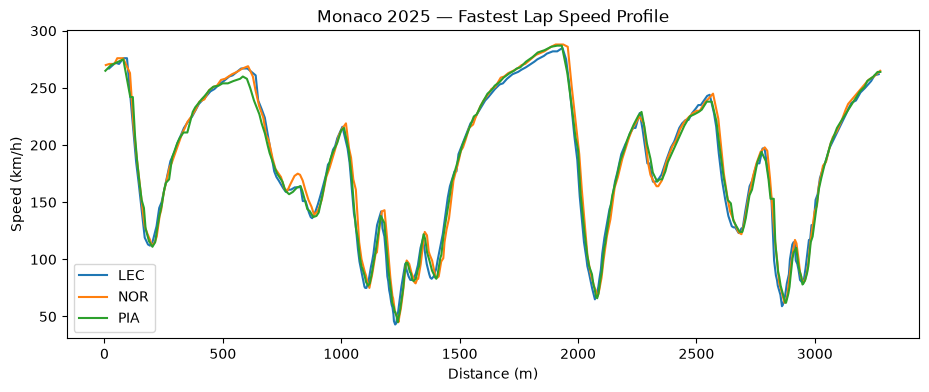

In [14]:
for circuit in circuits:
    subset = telemetry_master.loc[
        telemetry_master[
            "circuit"
        ].eq(circuit)
    ]

    fig, ax = plt.subplots(
        figsize=(11, 4)
    )

    for driver, driver_df in (
        subset.groupby("driver")
    ):
        driver_df = (
            driver_df
            .sort_values(
                "distance_m"
            )
        )

        ax.plot(
            driver_df["distance_m"],
            driver_df["speed_kmh"],
            label=driver
        )

    ax.set_title(
        f"{circuit} 2025 — "
        "Fastest Lap Speed Profile"
    )

    ax.set_xlabel("Distance (m)")
    ax.set_ylabel("Speed (km/h)")
    ax.legend()

    plt.show()

## 15. Final Schema Audit

In [15]:
schema_audit = pd.DataFrame({
    "column": telemetry_master.columns,
    "dtype": [
        str(telemetry_master[c].dtype)
        for c in telemetry_master.columns
    ],
    "missing": [
        int(
            telemetry_master[c]
            .isna()
            .sum()
        )
        for c in telemetry_master.columns
    ],
    "missing_pct": [
        round(
            telemetry_master[c]
            .isna()
            .mean()
            * 100,
            2
        )
        for c in telemetry_master.columns
    ],
    "nunique": [
        telemetry_master[c]
        .nunique(
            dropna=True
        )
        for c in telemetry_master.columns
    ]
})

display(schema_audit)

assert (
    telemetry_master.columns.tolist()
    == OUTPUT_COLUMNS
)

assert telemetry_master.shape[1] == 27

print(
    "✅ Exactly 27 output columns."
)

,column,dtype,missing,missing_pct,nunique
0,rpm,float64,0,0.00,2422
1,speed_kmh,float64,0,0.00,295
2,gear,int64,0,0.00,8
3,throttle_pct,float64,0,0.00,99
4,brake,bool,0,0.00,2
5,drs,int64,0,0.00,4
6,Source,object,0,0.00,1
7,distance_m,float64,0,0.00,4630
8,Date_pos,datetime64[ns],30,0.65,3739
9,Status,object,30,0.65,1


✅ Exactly 27 output columns.


## 16. Export Corrected CSV Files

File utama menggunakan nama yang sama dengan output sebelumnya sehingga bisa menggantikan CSV lama.

In [16]:
telemetry_path = (
    OUTPUT_DIR
    / "fastf1_telemetry_2025_selected_circuits.csv"
)

summary_path = (
    OUTPUT_DIR
    / "fastf1_fastest_lap_summary_2025.csv"
)

audit_path = (
    OUTPUT_DIR
    / "fastf1_position_merge_audit_2025.csv"
)

errors_path = (
    OUTPUT_DIR
    / "fastf1_extraction_errors_2025.csv"
)

telemetry_master.to_csv(
    telemetry_path,
    index=False
)

fastest_lap_summary.to_csv(
    summary_path,
    index=False
)

position_merge_audit.to_csv(
    audit_path,
    index=False
)

if not extraction_errors.empty:
    extraction_errors.to_csv(
        errors_path,
        index=False
    )

print(
    "Saved:",
    telemetry_path,
    telemetry_master.shape
)

print(
    "Saved:",
    summary_path,
    fastest_lap_summary.shape
)

print(
    "Saved:",
    audit_path,
    position_merge_audit.shape
)

if not extraction_errors.empty:
    print(
        "Saved:",
        errors_path,
        extraction_errors.shape
    )

Saved: /home/user/projects/avd-uts/outputs/fastf1_telemetry_2025_selected_circuits.csv (4630, 27)
Saved: /home/user/projects/avd-uts/outputs/fastf1_fastest_lap_summary_2025.csv (15, 17)
Saved: /home/user/projects/avd-uts/outputs/fastf1_position_merge_audit_2025.csv (15, 10)


## 17. Final Tableau Readiness Check

In [17]:
critical_numeric = [
    "rpm",
    "speed_kmh",
    "gear",
    "throttle_pct",
    "drs",
    "distance_m",
    "x",
    "y",
    "z",
    "lap_time_seconds",
    "time_seconds",
    "session_time_seconds",
]

readiness = []

for col in critical_numeric:
    readiness.append({
        "field": col,
        "dtype": str(
            telemetry_master[
                col
            ].dtype
        ),
        "missing_pct": round(
            telemetry_master[
                col
            ].isna().mean()
            * 100,
            2
        ),
        "min": pd.to_numeric(
            telemetry_master[col],
            errors="coerce"
        ).min(),
        "max": pd.to_numeric(
            telemetry_master[col],
            errors="coerce"
        ).max(),
    })

readiness = pd.DataFrame(
    readiness
)

display(readiness)

print(
    "Circuits:",
    sorted(
        telemetry_master[
            "circuit"
        ].unique()
    )
)

print(
    "Circuit-driver combinations:",
    telemetry_master[
        ["circuit", "driver"]
    ]
    .drop_duplicates()
    .shape[0]
)

print()
print(
    "✅ Tableau-ready output generated."
)
print(
    "Use this file:"
)
print(
    telemetry_path
)

,field,dtype,missing_pct,min,max
0,rpm,float64,0.00,4704.000000,12582.000000
1,speed_kmh,float64,0.00,43.000000,339.000000
2,gear,int64,0.00,1.000000,8.000000
3,throttle_pct,float64,0.00,0.000000,100.000000
4,drs,int64,0.00,0.000000,14.000000
5,distance_m,float64,0.00,0.214167,6928.799444
6,x,float64,0.65,-8233.000000,11067.000000
7,y,float64,0.65,-15770.000000,15883.000000
8,z,float64,0.65,476.000000,7848.000000
9,lap_time_seconds,float64,0.00,67.924000,106.174000


Circuits: ['Austria', 'Belgium', 'Great Britain', 'Italy', 'Monaco']
Circuit-driver combinations: 15

✅ Tableau-ready output generated.
Use this file:
/home/user/projects/avd-uts/outputs/fastf1_telemetry_2025_selected_circuits.csv
